# 03 — Country-Level Analysis
Cross-country comparisons and outlier detection.

In [1]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)

In [2]:
with open(os.path.join("..", "data", "processed.pkl"), "rb") as f:
    df = pickle.load(f)

df["date"] = pd.to_datetime(df["date"])
print(f"Vaccination data: {df.shape}")

Vaccination data: (62980, 21)


In [3]:
# grab country metadata (continent, population, gdp) from the main OWID dataset
# only need a few columns so we filter early
owid_url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
cols_needed = ["location", "continent", "population", "gdp_per_capita"]
print("Fetching OWID metadata...")
owid = pd.read_csv(owid_url, usecols=cols_needed)

# take the latest non-null row per country
meta = owid.dropna(subset=["continent"]).groupby("location").first().reset_index()
print(f"Got metadata for {len(meta)} countries")
meta.head()

Fetching OWID metadata...


Got metadata for 243 countries


,location,continent,gdp_per_capita,population
0,Afghanistan,Asia,1803.99,41128772
1,Albania,Europe,11803.43,2842318
2,Algeria,Africa,13913.84,44903228
3,American Samoa,Oceania,NaN,44295
4,Andorra,Europe,NaN,79843


In [4]:
# latest vaccination snapshot per country
latest = df.sort_values("date").groupby("location").last().reset_index()
latest = latest.merge(meta, on="location", how="left")
latest = latest.dropna(subset=["people_fully_vaccinated_per_hundred"])
print(f"Countries with latest data: {len(latest)}")

Countries with latest data: 221


## 1. Top 20 countries by fully vaccinated %

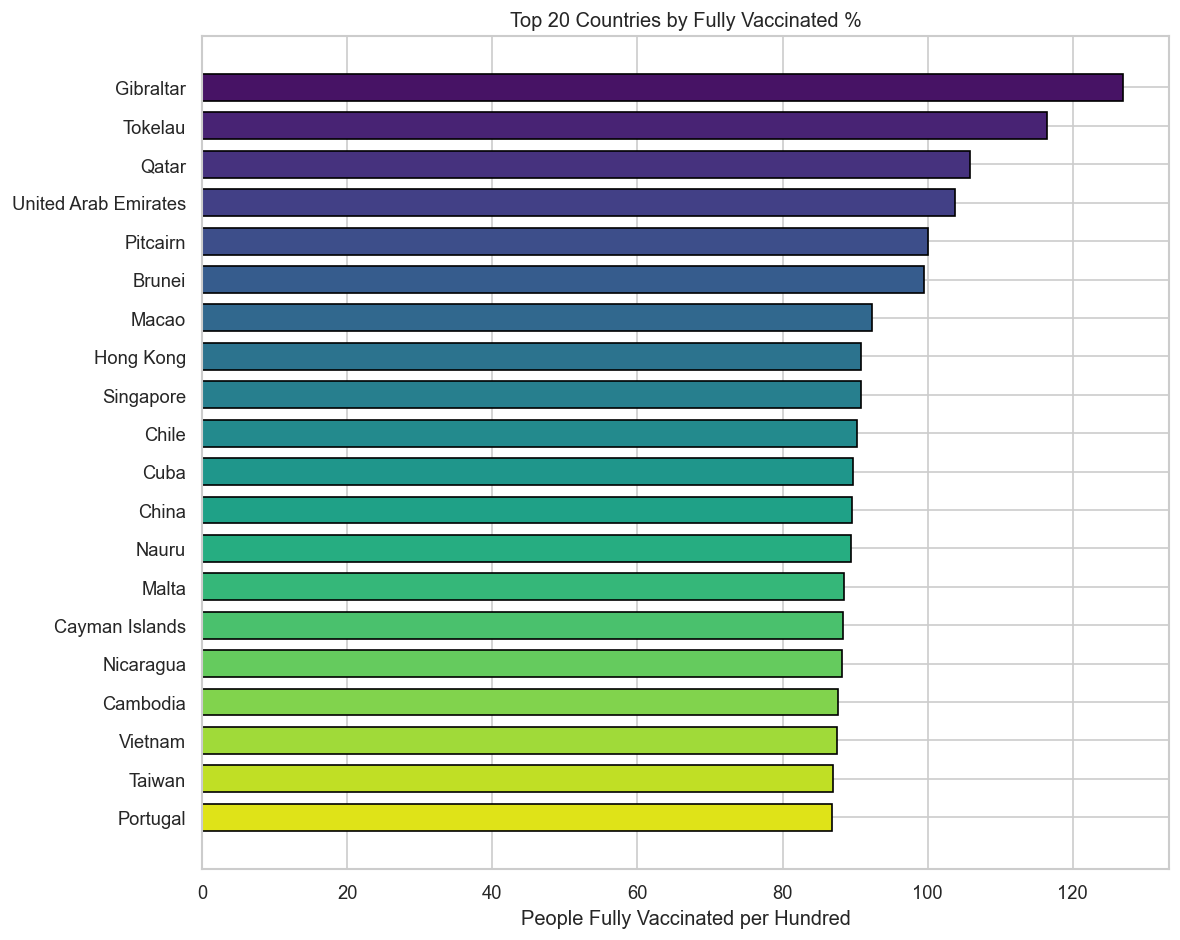

In [5]:
top20 = latest.nlargest(20, "people_fully_vaccinated_per_hundred")

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette("viridis", 20)
ax.barh(range(len(top20)), top20["people_fully_vaccinated_per_hundred"].values,
        color=colors, edgecolor="black", height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20["location"].values)
ax.invert_yaxis()
ax.set_xlabel("People Fully Vaccinated per Hundred")
ax.set_title("Top 20 Countries by Fully Vaccinated %")
fig.tight_layout()
fig.savefig(os.path.join(OUT, "top20_fully_vaccinated.png"))
plt.show()

## 2. GDP vs vaccination rate scatter

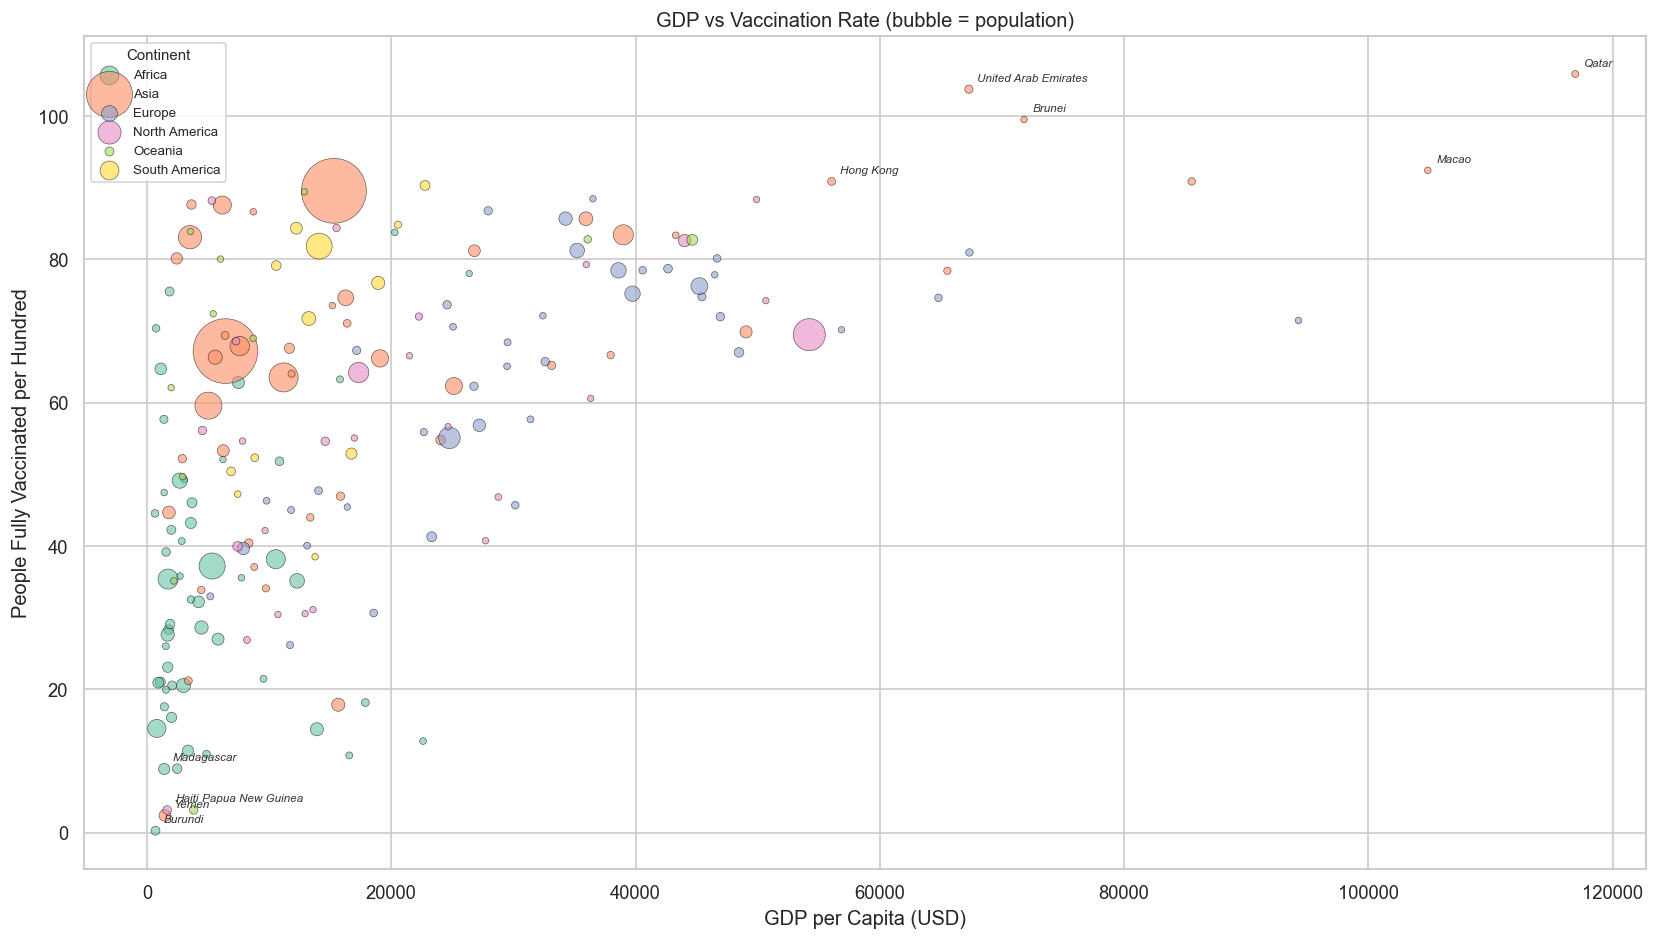

In [6]:
scatter_df = latest.dropna(subset=["gdp_per_capita", "population", "continent"]).copy()

# scale bubble sizes so they're visible but not insane
scatter_df["bubble"] = (scatter_df["population"] / scatter_df["population"].max()) * 1500 + 15

continents = scatter_df["continent"].unique()
palette = dict(zip(sorted(continents), sns.color_palette("Set2", len(continents))))

fig, ax = plt.subplots(figsize=(14, 8))
for cont in sorted(continents):
    chunk = scatter_df[scatter_df["continent"] == cont]
    ax.scatter(chunk["gdp_per_capita"], chunk["people_fully_vaccinated_per_hundred"],
              s=chunk["bubble"], alpha=0.6, label=cont, color=palette[cont],
              edgecolors="black", linewidth=0.4)

# label outliers: top 5 and bottom 5 by vaccination rate
outliers = pd.concat([
    scatter_df.nlargest(5, "people_fully_vaccinated_per_hundred"),
    scatter_df.nsmallest(5, "people_fully_vaccinated_per_hundred")
])
for _, row in outliers.iterrows():
    ax.annotate(row["location"],
                xy=(row["gdp_per_capita"], row["people_fully_vaccinated_per_hundred"]),
                xytext=(5, 5), textcoords="offset points", fontsize=7,
                fontstyle="italic", color="#333")

ax.set_xlabel("GDP per Capita (USD)")
ax.set_ylabel("People Fully Vaccinated per Hundred")
ax.set_title("GDP vs Vaccination Rate (bubble = population)")
ax.legend(title="Continent", fontsize=8, title_fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "gdp_vs_vaccination_scatter.png"))
plt.show()

## 3. Mean vaccination rate by continent

In [7]:
continent_stats = (
    latest.dropna(subset=["continent"])
    .groupby("continent")["people_fully_vaccinated_per_hundred"]
    .agg(["mean", "median", "std", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
    .rename(columns={"mean": "Mean %", "median": "Median %",
                     "std": "Std Dev", "count": "Countries"})
)

continent_stats.style.background_gradient(cmap="YlGn", subset=["Mean %"])

,Mean %,Median %,Std Dev,Countries
continent,,,,
Oceania,71.120000,76.200000,25.320000,18
Europe,66.950000,71.450000,17.930000,51
Asia,66.250000,67.880000,23.950000,49
South America,65.910000,71.720000,18.100000,13
North America,58.080000,59.430000,19.940000,34
Africa,35.400000,33.830000,19.840000,54


## 4. Outlier countries (>2.5 std from mean)

In [8]:
col = "people_fully_vaccinated_per_hundred"
mean_val = latest[col].mean()
std_val = latest[col].std()
threshold = 2.5 * std_val

outlier_countries = latest[
    (latest[col] > mean_val + threshold) |
    (latest[col] < mean_val - threshold)
][["location", col]].sort_values(col, ascending=False)

print(f"Mean: {mean_val:.2f}, Std: {std_val:.2f}, Threshold: ±{threshold:.2f}")
print(f"\nOutlier countries ({len(outlier_countries)}):")
for _, row in outlier_countries.iterrows():
    direction = "HIGH" if row[col] > mean_val else "LOW"
    print(f"  {row['location']:30s} {row[col]:6.2f}%  [{direction}]")

Mean: 58.01, Std: 24.47, Threshold: ±61.17

Outlier countries (1):
  Gibraltar                      126.89%  [HIGH]
